In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
sys.path.insert(0, str(Path('.')))

from growth_analysis.funnel import FunnelAnalysis

In [2]:
# Constants
DATA_DIR = Path('..') / 'data' / 'synthetic'
LOOKBACK_DAYS = 90

In [3]:
events = pd.read_csv(DATA_DIR / 'events.csv', parse_dates=['occurred_at'])

# Apply lookback filter
cutoff = events['occurred_at'].max() - pd.Timedelta(days=LOOKBACK_DAYS)
recent_events = events[events['occurred_at'] >= cutoff]
print(f"{len(recent_events):,} events in last {LOOKBACK_DAYS} days")

34,851 events in last 90 days


In [4]:
# Activation funnel
activation = FunnelAnalysis(
    steps=['page_view', 'signup', 'feature_used', 'report_created']
)
results = activation.compute(recent_events)
df = FunnelAnalysis.to_dataframe(results)
df

,step,event,users,conversion_from_top,conversion_from_previous,dropped
0,0,page_view,1982,1.000000,1.000000,0
1,1,signup,1088,0.548940,0.548940,894
2,2,feature_used,483,0.243693,0.443934,605
3,3,report_created,241,0.121594,0.498965,242


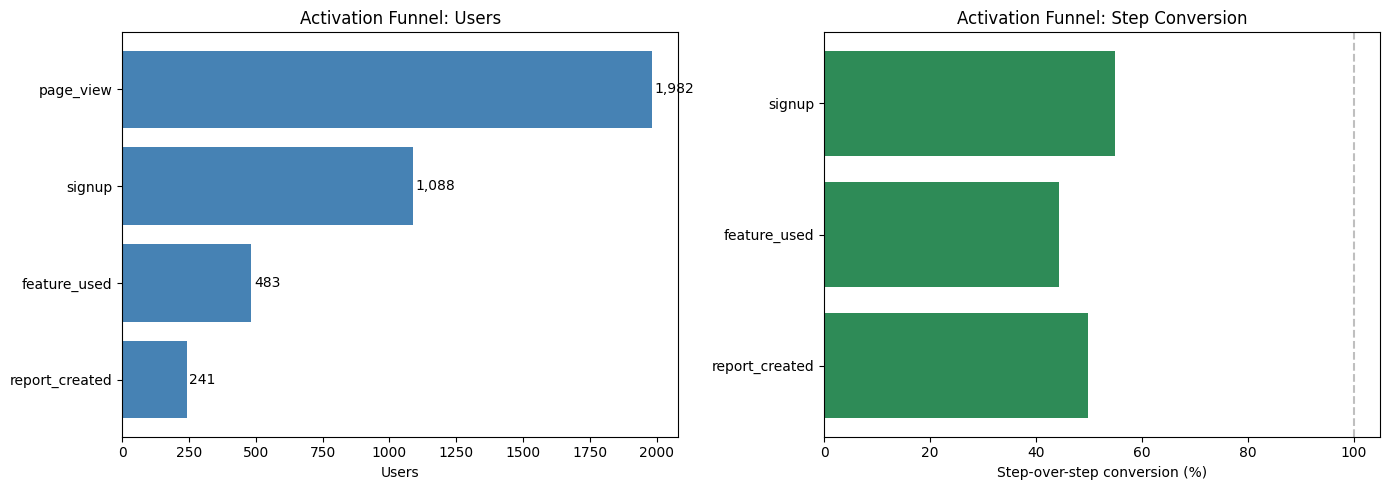

Overall: 1,982 → 241  (12.2% top-of-funnel)


In [5]:
# Funnel bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute users
axes[0].barh(df['event'][::-1], df['users'][::-1], color='steelblue')
axes[0].set_xlabel('Users')
axes[0].set_title('Activation Funnel: Users')
for i, (users, row) in enumerate(zip(df['users'][::-1], df.iloc[::-1].itertuples())):
    axes[0].text(users + 10, i, f'{users:,}', va='center')

# Right: step-over-step conversion
axes[1].barh(
    df['event'][1:][::-1],
    df['conversion_from_previous'][1:][::-1] * 100,
    color='seagreen'
)
axes[1].set_xlabel('Step-over-step conversion (%)')
axes[1].set_title('Activation Funnel: Step Conversion')
axes[1].axvline(100, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(f"Overall: {df.iloc[0]['users']:,} → {df.iloc[-1]['users']:,}  ({df.iloc[-1]['conversion_from_top']:.1%} top-of-funnel)")

In [6]:
# Conversion funnel
conversion = FunnelAnalysis(
    steps=['signup', 'feature_used', 'invite_sent', 'upgrade_clicked']
)
conv_results = conversion.compute(recent_events)
FunnelAnalysis.to_dataframe(conv_results)

,step,event,users,conversion_from_top,conversion_from_previous,dropped
0,0,signup,2098,1.000000,1.000000,0
1,1,feature_used,770,0.367016,0.367016,1328
2,2,invite_sent,201,0.095806,0.261039,569
3,3,upgrade_clicked,172,0.081983,0.855721,29
